<a href="https://colab.research.google.com/github/lazybear-0425/EWC_Observation/blob/main/2025-03-25_10_55_38.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 - Life Lone Learning
 - Elastic Weight Consolidation (EWC)
    - [教學](https://www.kaggle.com/code/hughiephan/elastic-weight-consolidation-on-minst)
    - [Paper](https://arxiv.org/pdf/1612.00796)
    - 公式 $\mathcal{L}(\theta) = \mathcal{L}_B(\theta) + \frac\lambda2\sum^n_{i=1}F_i(\theta_i - \theta^*_{A,i})^2$
        - B是指目前任務，A是指前一個任務
 - [教學2](https://github.com/ContinualAI/colab/blob/master/notebooks/intro_to_continual_learning.ipynb)

In [1]:
import torch
from torch import nn
from torchvision.transforms import Compose, ToTensor, Normalize, RandomRotation, Lambda
import numpy as np
from torchvision.datasets import MNIST as FashionMNIST
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch.nn import CrossEntropyLoss
from torch.optim import Adam, SGD
from torch.nn.functional import cross_entropy

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
import random

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True  # 確保 CuDNN 使用確定性算法
torch.backends.cudnn.benchmark = False  # 禁止自適應選擇最佳內核，確保結果可重現

In [4]:
batch_size = 256
epochs = 10
task = 2

 - [ToTensor](https://pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html)

In [5]:
def trans_compose(i=0):
    return Compose([
        # lambda x : np.rot90(x, i, axes=[0, 1]).copy(), # 使連續
        # lambda x: np.expand_dims(x, axis=-1),  # 因為ToTensor要PIL or ndarray(H x W x C)，之後轉成Tensor(C x H x W)
        ToTensor(),
        # Lambda(lambda x : x / 255.),
        RandomRotation((90 * i, 90 * i)),
        Normalize(mean=[0.0], std=[1])
    ])

In [6]:
# preprocessing
# train_task_1 = FashionMNIST('data', train=True, transform=trans_compose(0), download=True)
# train_task_2 = FashionMNIST('data', train=True, transform=trans_compose(1), download=True)

test_task_1 = FashionMNIST('data', train=False, transform=trans_compose(0), download=True)
test_task_2 = FashionMNIST('data', train=False, transform=trans_compose(1), download=True)

task_1_loader = DataLoader(test_task_1, batch_size=batch_size, pin_memory=True)
task_2_loader = DataLoader(test_task_2, batch_size=batch_size, pin_memory=True)

100%|██████████| 9.91M/9.91M [00:11<00:00, 895kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.17MB/s]


In [7]:
class Module(nn.Module):
    def __init__(self):
        super(Module, self).__init__()
        # self.classifier = nn.Sequential(
        #     nn.Conv2d(1, 10, kernel_size=5),
        #     nn.MaxPool2d(2),
        #     nn.ReLU(),
        #     nn.Conv2d(10, 20, kernel_size=5),
        #     nn.Dropout2d(),
        #     nn.MaxPool2d(2),
        #     nn.ReLU(),
        # )
        # self.dense = nn.Sequential(
        #     nn.Linear(320, 50),
        #     nn.ReLU(),
        #     nn.Dropout(),
        #     nn.Linear(50, 10)
        # )
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(10)
        )
    def forward(self, X):
        # return self.dense(self.classifier(X).view(-1, 320))
        return self.net(X)

In [8]:
def evaluate(model, dataloader, num_data, num_task=-1):
    if num_task < 0: raise ValueError("Task Number is Missing")

    test_acc = 0
    test_loss = 0
    with torch.no_grad():
        model.eval()
        for data in dataloader:
            img, label = data
            img, label = img.to(device), label.to(device).long()
            output = model(img)
            test_loss += cross_entropy(output, label)
            test_acc += (output.argmax(1) == label).sum()
    print('\033[33m' +
          f'Task {num_task} Acc: {test_acc / num_data: .4f}, Loss: {test_loss / num_data: .4f}' +
          '\033[0m')

In [9]:
def training_Setting(model):
    optimizer = Adam(model.parameters())
    loss = CrossEntropyLoss()
    return optimizer, loss

 - Fisher Matrix
     - 儲存權重對模型重要性
     - 計算方法
         - [LINK](https://github.com/db434/EWC)
             - 這個版本是**取樣** $\rightarrow$ 計算梯度
         - 這邊的範例程式碼是直接**整個資料**來計算梯度
         - 公式
             - $F_j = \frac1m \sum^m_{i=1}(\frac{\partial \log (P(x_i|\theta_j))}{\partial \theta_j})^2$

In [10]:
# EWC
optim_para = {}
fisher_matrix = {}
ewc_lambda = 1

def record_parameter(model, train_data, optimizer, num_task=-1):
    if num_task < 0: raise ValueError("Task Number is Missing")
    global optim_para, fisher_matrix, ewc_lambda
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, pin_memory=True)
    model.train()
    optimizer.zero_grad()

    fisher_matrix[num_task] = {}
    optim_para[num_task] = {}

    # Initialize Fisher Matrix
    for name, param in model.named_parameters():
        fisher_matrix[num_task][name] = torch.zeros_like(param.data)

    idx = 0
    bound = ((60000//batch_size)*0.8)//1
    print('Bound is', bound, 'times')
    # Calculate Fisher Matrix
    for data in train_loader:
        if idx == bound: break
        else: idx += 1

        img, label = data
        img, label = img.to(device), label.to(device).long()
        output = model(img)
        output_loss = cross_entropy(output, label)
        output_loss.backward()

        for name, param in model.named_parameters():
            if param.grad is not None:
                fisher_matrix[num_task][name] += param.grad.data.clone().pow(2)

    # Average Fisher Matrix
    for name, param in model.named_parameters():
        fisher_matrix[num_task][name] /= idx #len(train_loader)

    # Save optimal parameters
    for name, param in model.named_parameters():
        optim_para[num_task][name] = param.data.clone()

In [11]:
def training(model, test_loader : list, test_num : list, epochs = 10,  num_task=-1):
    if num_task < 0: raise ValueError("Task Number is Missing")
    global optim_para, fisher_matrix, ewc_lambda
    print(f'Task {num_task} Start!')

    train_data = FashionMNIST('data', train=True, transform=trans_compose(num_task), download=True)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, pin_memory=True)
    # plt.imshow(train_data[0][0].reshape(28, 28), cmap='gray')
    # plt.title('Task' + str(num_task))
    # plt.show()

    # optimizer, loss = training_Setting(model)
    optimizer = Adam(model.parameters()) #SGD(model.parameters(), lr=0.01, momentum=0.9)

    for i in range(epochs):
        model.train()
        train_acc = 0
        train_loss = 0
        for data in train_loader:
            optimizer.zero_grad()

            img, label = data
            img, label = img.to(device), label.to(device).long()
            output = model(img)
            output_loss = cross_entropy(output, label)
            # Record
            train_acc += (output.argmax(1) == label).sum()
            # BP
            ewc_loss = 0
            for t in range(num_task):
                for name, param in model.named_parameters():
                    if t in optim_para:
                        fisher = fisher_matrix[t][name]
                        optim = optim_para[t][name]
                        if fisher.requires_grad == True or optim.requires_grad == True:
                            raise NotImplementedError('Frozen it!')
                        # output_loss += ewc_lambda * (fisher * (optim - param).pow(2)).sum() # .detach()
                        ewc_loss += (fisher * (optim - param).pow(2)).sum() * ewc_lambda
            # if tmp != 0: print(tmp)
            output_loss += ewc_loss
            train_loss += output_loss.detach()
            output_loss.backward()
            optimizer.step()
        print(f'Epoch\t{i + 1}\tAcc: {train_acc / len(train_data): .4f}, Loss: {train_loss / len(train_data): .4f}')
    record_parameter(model, train_data, optimizer, num_task=num_task)
    # Evaluate Task 0 & 1
    task_id = 0
    for num_data, loader in zip(test_num, test_loader):
        evaluate(model, loader, num_data, task_id)
        task_id = task_id + 1
    print() # End of Training

 - nn.Module
    - named_pa​​rameters()
         - 給出網絡層的名字和參數的迭代器
    - parameters()
         - 參數的迭代器
    - [Reference](https://blog.csdn.net/qq_36530992/article/details/102729585)

In [12]:
model = Module().to(device)

for i in range(task):
    training(model, [task_1_loader, task_2_loader], [len(test_task_1), len(test_task_2)], num_task=i, epochs=epochs)

Task 0 Start!
Epoch	1	Acc:  0.8191, Loss:  0.0033
Epoch	2	Acc:  0.8917, Loss:  0.0017
Epoch	3	Acc:  0.9042, Loss:  0.0014
Epoch	4	Acc:  0.9107, Loss:  0.0013
Epoch	5	Acc:  0.9143, Loss:  0.0012
Epoch	6	Acc:  0.9178, Loss:  0.0012
Epoch	7	Acc:  0.9198, Loss:  0.0011
Epoch	8	Acc:  0.9212, Loss:  0.0011
Epoch	9	Acc:  0.9231, Loss:  0.0011
Epoch	10	Acc:  0.9238, Loss:  0.0011
Bound is 187.0 times
Task 0 Acc:  0.9238, Loss:  0.0011
Task 1 Acc:  0.1372, Loss:  0.0264

Task 1 Start!
Epoch	1	Acc:  0.4232, Loss:  0.0105
Epoch	2	Acc:  0.7666, Loss:  0.0036
Epoch	3	Acc:  0.8383, Loss:  0.0028
Epoch	4	Acc:  0.8630, Loss:  0.0025
Epoch	5	Acc:  0.8749, Loss:  0.0024
Epoch	6	Acc:  0.8820, Loss:  0.0023
Epoch	7	Acc:  0.8858, Loss:  0.0022
Epoch	8	Acc:  0.8891, Loss:  0.0022
Epoch	9	Acc:  0.8910, Loss:  0.0021
Epoch	10	Acc:  0.8922, Loss:  0.0021
Bound is 187.0 times
Task 0 Acc:  0.3915, Loss:  0.0101
Task 1 Acc:  0.8956, Loss:  0.0015



 - Task 0

Accuracy 0.3915
Classification Report
              precision    recall  f1-score   support

    0 - zero       0.74      0.71      0.72       980
     1 - one       0.44      0.00      0.01      1135
     2 - two       0.38      0.41      0.39      1032
   3 - three       0.38      0.27      0.31      1010
    4 - four       0.14      0.50      0.22       982
    5 - five       0.33      0.05      0.09       892
     6 - six       0.60      0.75      0.66       958
   7 - seven       0.78      0.48      0.59      1028
   8 - eight       0.32      0.24      0.27       974
    9 - nine       0.55      0.55      0.55      1009

    accuracy                           0.39     10000
   macro avg       0.47      0.39      0.38     10000
weighted avg       0.47      0.39      0.38     10000



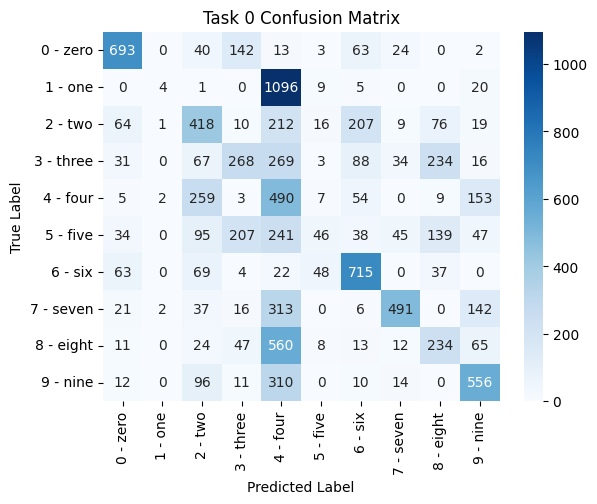

In [13]:
true_label = []
pred_label = []
with torch.no_grad():
    for data in task_1_loader:
        img, label = data
        img, label = img.to(device), label.to(device)
        output = model(img).argmax(1)
        true_label.extend(label.cpu().numpy())
        pred_label.extend(output.cpu().numpy())

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
print('\033[33m' + 'Accuracy' + '\033[0m', accuracy_score(true_label, pred_label))
print('\033[33m' + 'Classification Report' + '\033[0m',
      classification_report(true_label, pred_label, target_names=test_task_1.classes),
      sep='\n')
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_label, pred_label)
plt.cla(); plt.clf()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_task_1.classes, yticklabels=test_task_1.classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Task 0 Confusion Matrix")
plt.show()

 - Task 1

Accuracy 0.8956
Classification Report
              precision    recall  f1-score   support

    0 - zero       0.92      0.96      0.94       980
     1 - one       0.96      0.98      0.97      1135
     2 - two       0.90      0.82      0.86      1032
   3 - three       0.86      0.90      0.88      1010
    4 - four       0.88      0.91      0.90       982
    5 - five       0.89      0.81      0.85       892
     6 - six       0.91      0.94      0.92       958
   7 - seven       0.93      0.90      0.92      1028
   8 - eight       0.84      0.84      0.84       974
    9 - nine       0.87      0.88      0.87      1009

    accuracy                           0.90     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.90      0.90      0.90     10000



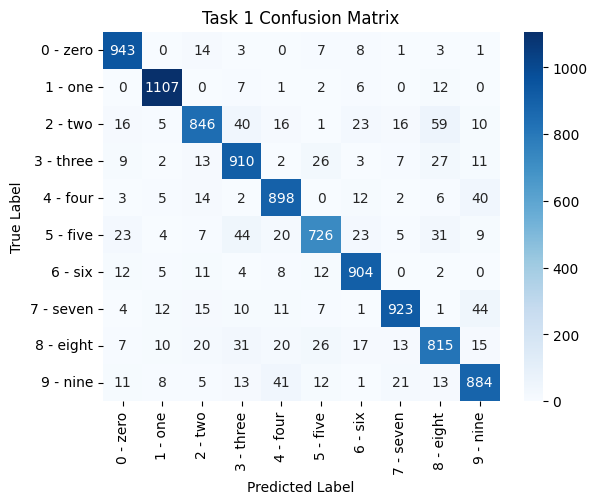

In [14]:
true_label = []
pred_label = []
with torch.no_grad():
    for data in task_2_loader:
        img, label = data
        img, label = img.to(device), label.to(device)
        output = model(img).argmax(1)
        true_label.extend(label.cpu().numpy())
        pred_label.extend(output.cpu().numpy())

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
print('\033[33m' + 'Accuracy' + '\033[0m', accuracy_score(true_label, pred_label))
print('\033[33m' + 'Classification Report' + '\033[0m',
      classification_report(true_label, pred_label, target_names=test_task_2.classes),
      sep='\n')
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_label, pred_label)
plt.cla(); plt.clf()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_task_2.classes, yticklabels=test_task_2.classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Task 1 Confusion Matrix")
plt.show()

net.1.weight
torch.Size([10, 784])
Max fisher is 0.02595 and it's parameter diff is 0.02805
Min Parameter diff is 0.69400 and it's fisher is 0.00000
fisher > parameter diff: 53
fisher <= parameter diff: 731


<Figure size 640x480 with 0 Axes>

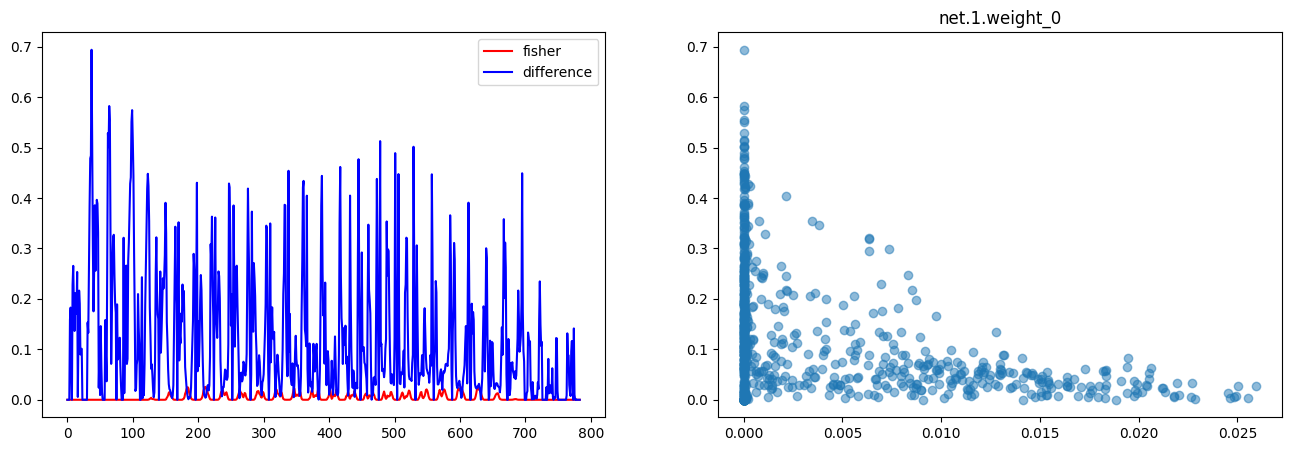

Max fisher is 0.02416 and it's parameter diff is 0.00275
Min Parameter diff is 0.76743 and it's fisher is 0.00000
fisher > parameter diff: 28
fisher <= parameter diff: 756


<Figure size 640x480 with 0 Axes>

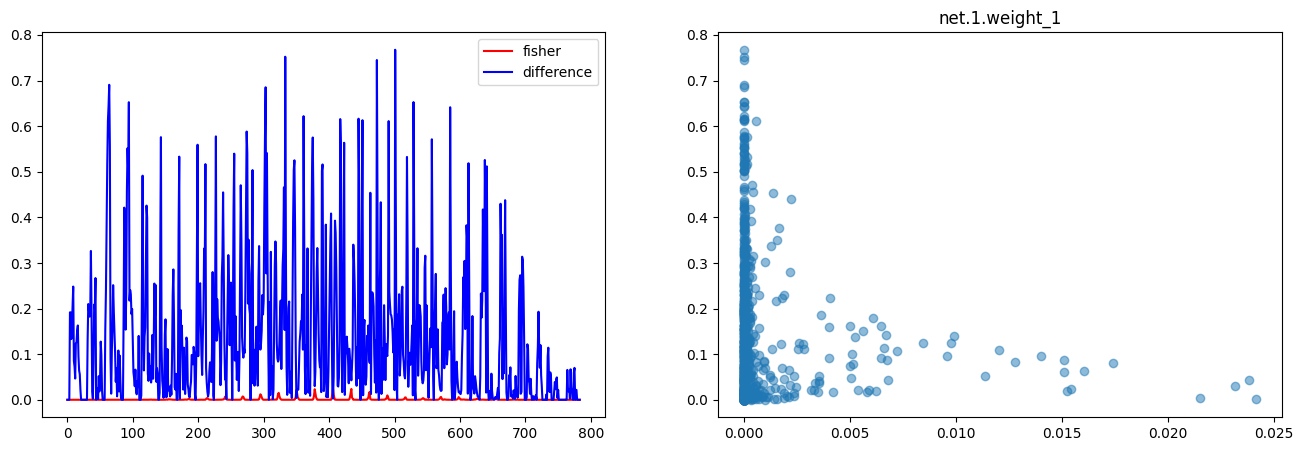

Max fisher is 0.05641 and it's parameter diff is 0.01395
Min Parameter diff is 0.72399 and it's fisher is 0.00003
fisher > parameter diff: 72
fisher <= parameter diff: 712


<Figure size 640x480 with 0 Axes>

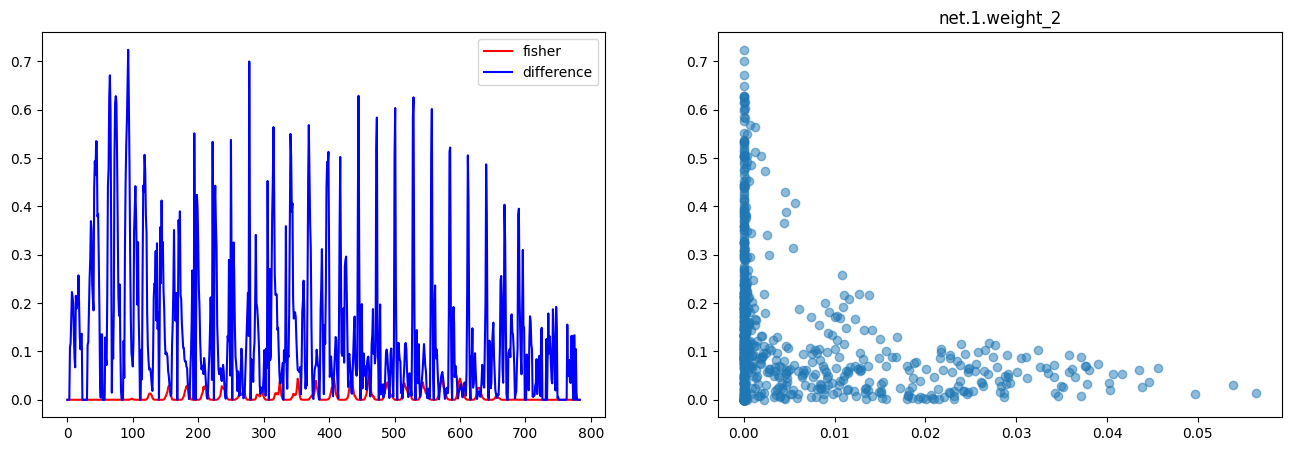

Max fisher is 0.00843 and it's parameter diff is 0.00462
Min Parameter diff is 0.70836 and it's fisher is 0.00001
fisher > parameter diff: 22
fisher <= parameter diff: 762


<Figure size 640x480 with 0 Axes>

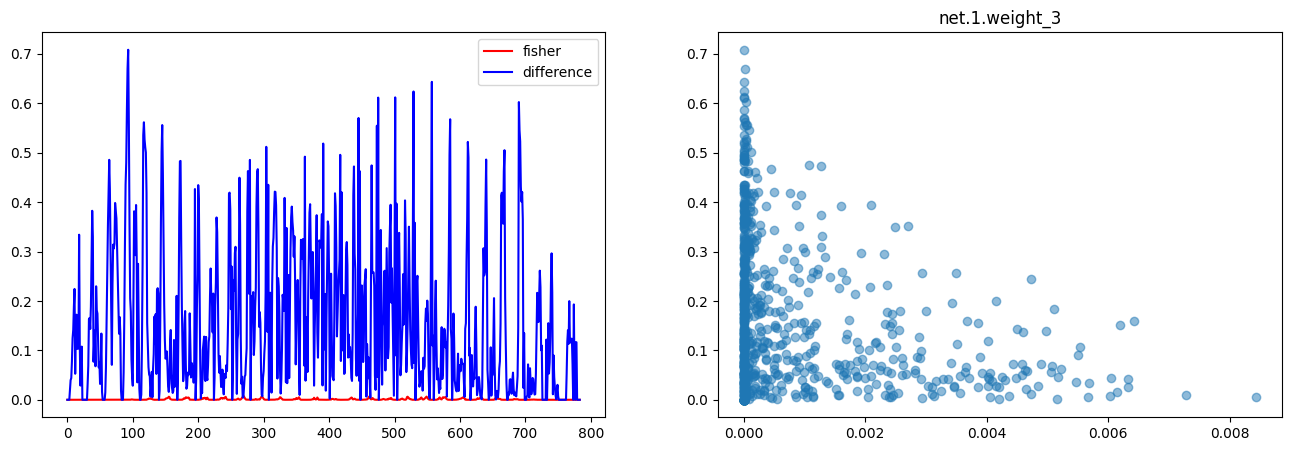

Max fisher is 0.00948 and it's parameter diff is 0.16206
Min Parameter diff is 0.74796 and it's fisher is 0.00001
fisher > parameter diff: 25
fisher <= parameter diff: 759


<Figure size 640x480 with 0 Axes>

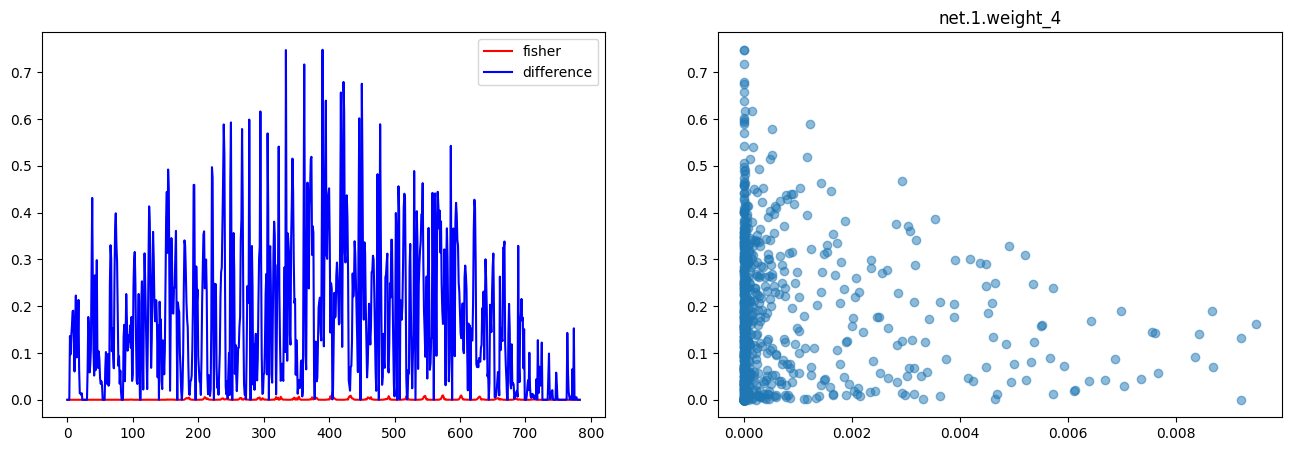

Max fisher is 0.01284 and it's parameter diff is 0.08104
Min Parameter diff is 0.98366 and it's fisher is 0.00000
fisher > parameter diff: 26
fisher <= parameter diff: 758


<Figure size 640x480 with 0 Axes>

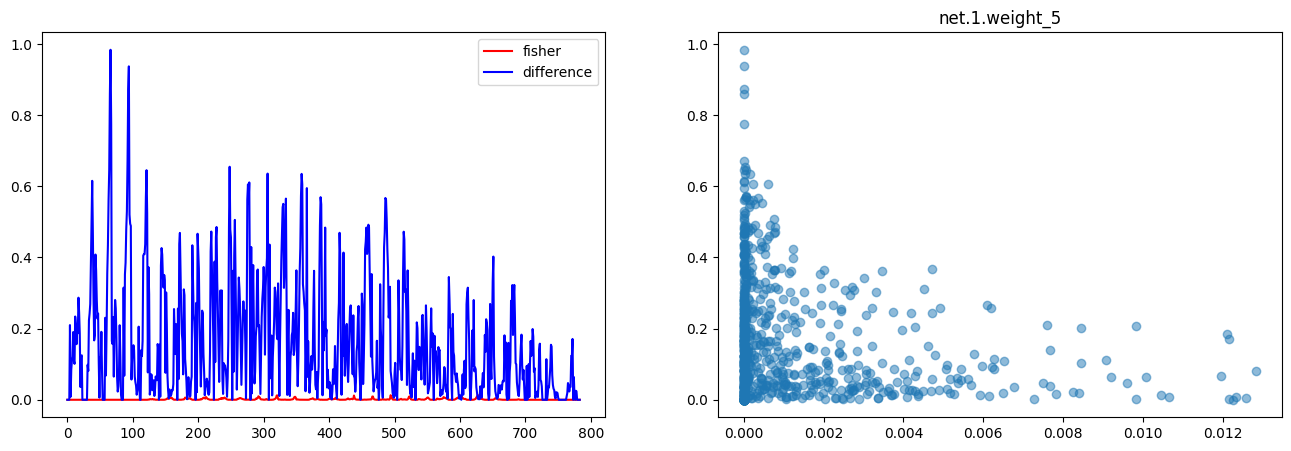

Max fisher is 0.02579 and it's parameter diff is 0.00583
Min Parameter diff is 0.67325 and it's fisher is 0.00001
fisher > parameter diff: 51
fisher <= parameter diff: 733


<Figure size 640x480 with 0 Axes>

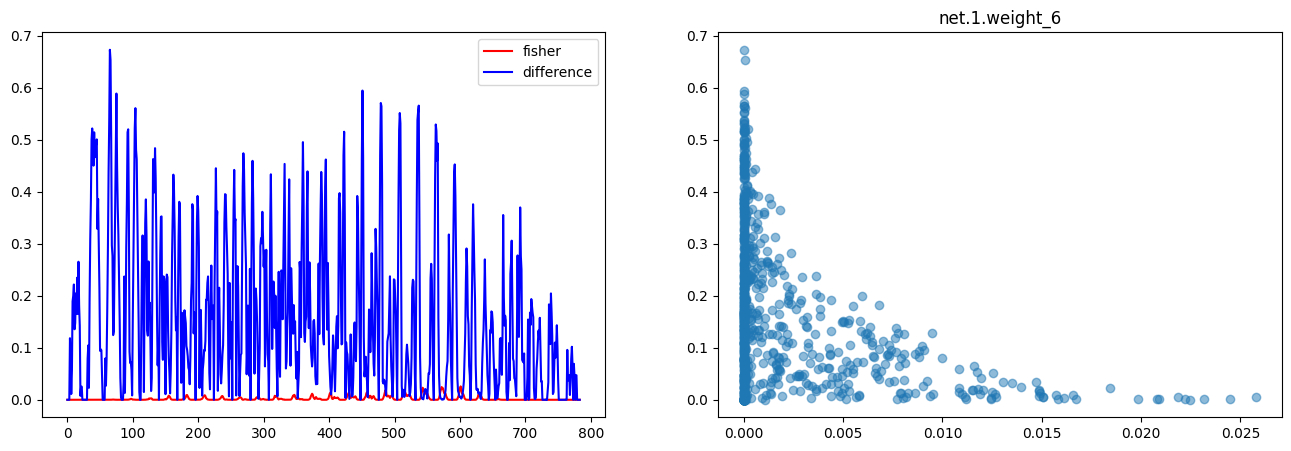

Max fisher is 0.00979 and it's parameter diff is 0.08968
Min Parameter diff is 0.60668 and it's fisher is 0.00000
fisher > parameter diff: 22
fisher <= parameter diff: 762


<Figure size 640x480 with 0 Axes>

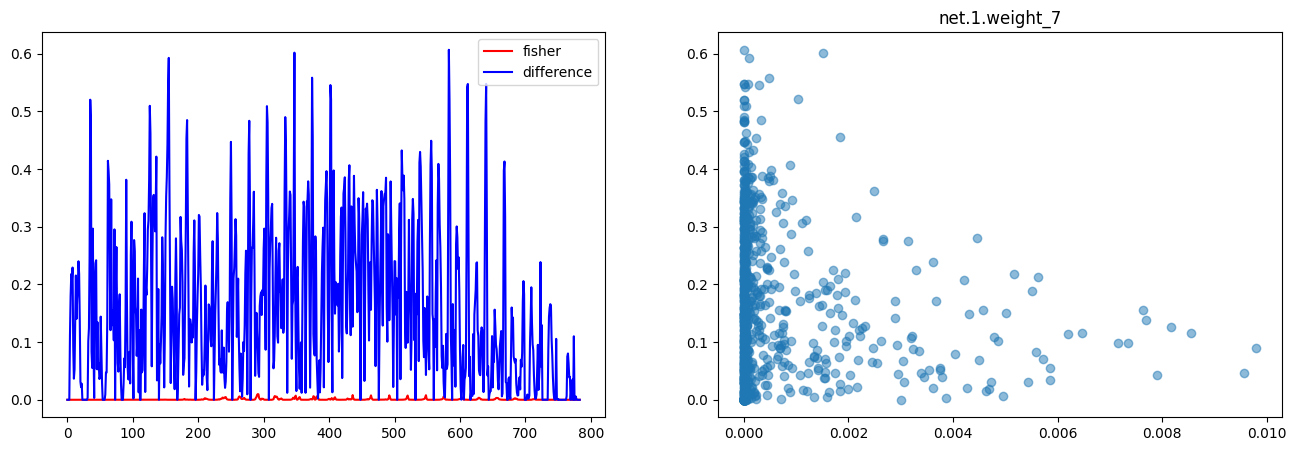

Max fisher is 0.03711 and it's parameter diff is 0.00563
Min Parameter diff is 0.71477 and it's fisher is 0.00000
fisher > parameter diff: 105
fisher <= parameter diff: 679


<Figure size 640x480 with 0 Axes>

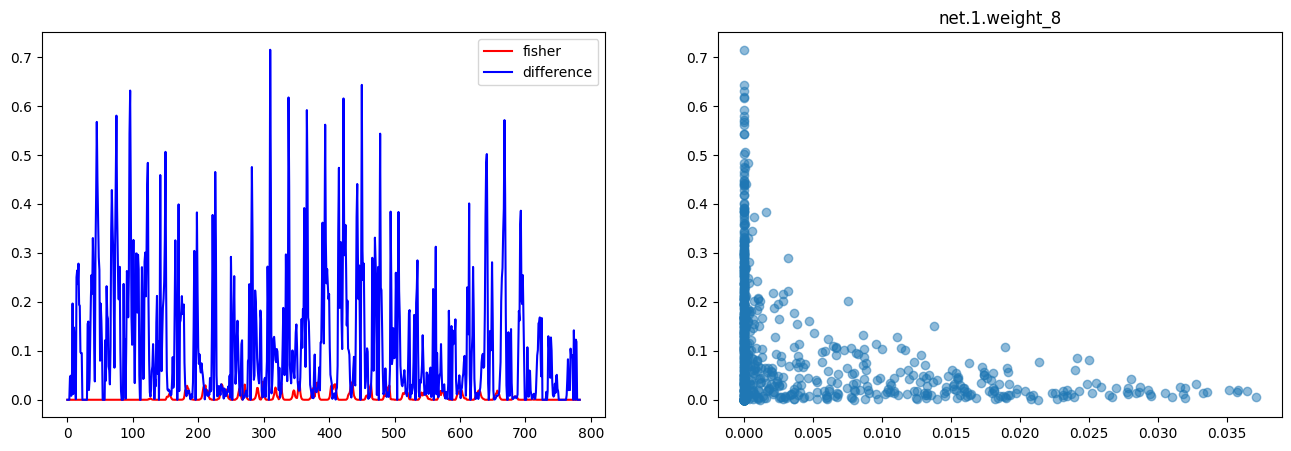

Max fisher is 0.01434 and it's parameter diff is 0.00872
Min Parameter diff is 0.71548 and it's fisher is 0.00000
fisher > parameter diff: 31
fisher <= parameter diff: 753


<Figure size 640x480 with 0 Axes>

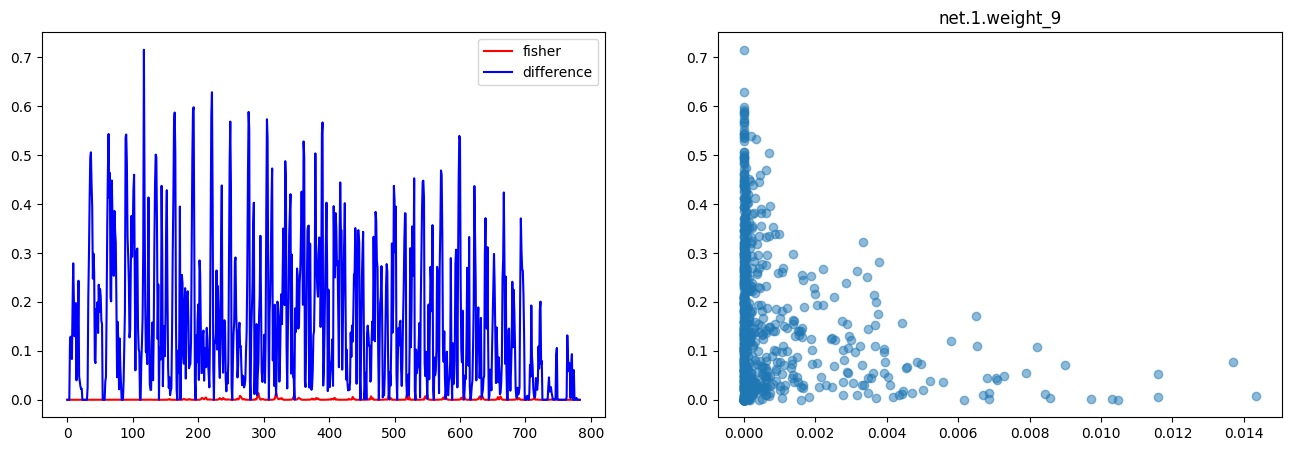


net.1.bias
torch.Size([10])
Max fisher is 0.09703 and it's parameter diff is 0.00661
Min Parameter diff is 0.58576 and it's fisher is 0.00106
fisher > parameter diff: 5
fisher <= parameter diff: 5


<Figure size 640x480 with 0 Axes>

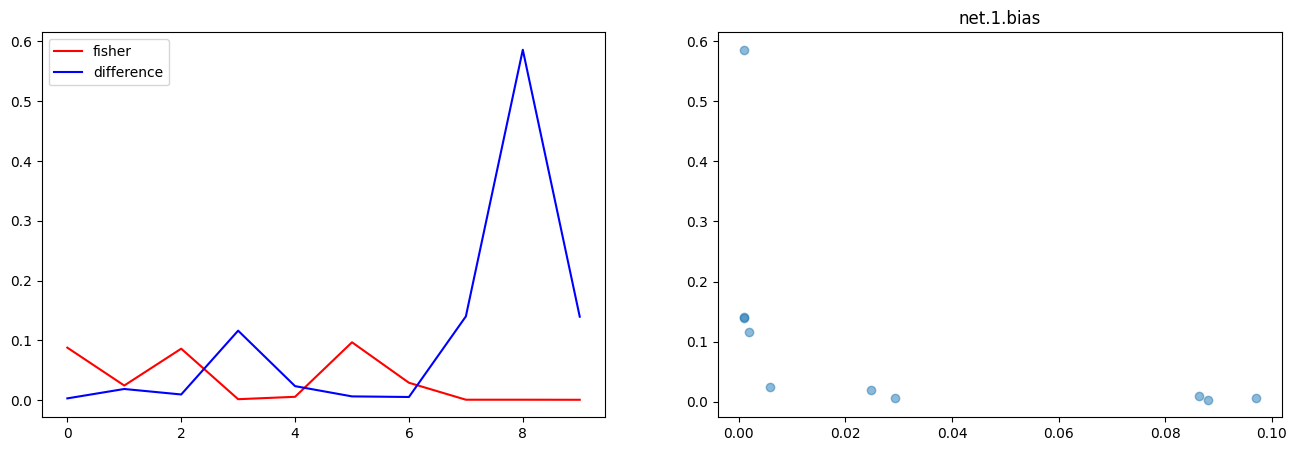

In [15]:
def plot(fisher_matrix, optim_para, param, name):
  plt.cla(); plt.clf()
  #print(fisher_matrix.shape, optim_para.shape, param.shape)
  fisher = fisher_matrix.cpu().detach()
  optim = optim_para.cpu().detach()
  param = param.cpu().detach()

  fisher_max = np.argmax(fisher)
  param_diff_max = np.argmax((optim - param).abs())
  print(f'Max fisher is {fisher[fisher_max]:.5f} and it\'s parameter diff is {(optim - param).abs()[fisher_max]:.5f}')
  print(f'Min Parameter diff is {(optim - param).abs()[param_diff_max]:.5f} and it\'s fisher is {fisher[param_diff_max]:.5f}')
  # compare
  print('fisher > parameter diff: {}'.format((fisher > (optim - param).abs()).sum()))
  print('fisher <= parameter diff: {}'.format((fisher <= (optim - param).abs()).sum()))

  # plot
  fig, ax = plt.subplots(1, 2, figsize=(16, 5)) # row, col
  ax[0].plot(fisher.reshape(-1), 'r', label='fisher')
  ax[0].plot((optim - param).abs().reshape(-1), 'b', label='difference')
  ax[0].legend()

  ax[1].scatter(fisher, (optim - param).abs().reshape(-1), alpha=0.5)
  plt.title(name)
  plt.show()

# test
idx = 0
for name, param in model.named_parameters():

  # Name
  print(name)
  print(param.detach().shape)

  if len(param.detach().shape) != 1:
    for i in range(param.detach().shape[0]):
      plot(fisher_matrix[0][name][i], optim_para[0][name][i], param[i], f'{name}_{i}')
  else:
    plot(fisher_matrix[0][name], optim_para[0][name], param, name)
  # END
  idx += 1
  print()

In [16]:
import datetime
import pytz

now = datetime.datetime.now(pytz.timezone('Asia/Taipei')).strftime("%Y-%m-%d_%H_%M_%S")
print(now)

2025-03-30_16_24_43
